In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import psutil
from scipy.stats import zscore

import torch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
from cuml.manifold import TSNE
from cuml.decomposition import PCA

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# SCENIC TFs

In [2]:
# read tf list
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
print(f"{len(tf_list)=}")
tf_list[:10]

len(tf_list)=1892


['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

# # Define Marker Genes from DEG

In [3]:
# %%time
# fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/sample_1_adata_basename_deg.parquet"

# df = pd.read_parquet(fpath)
# print(f"Raw data shape: {df.shape=}")
# df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# """THRESHOLDS"""

# # Define thresholds
# top_n_genes = 300 # unless there are not this many!
# min_logfc = 1.0
# max_padj = 0.05
# min_pct_group = 0.25
# # max_pct_ref = 0.25

# groups = [
#     'endothelial_cells',
#     'fibroblasts',
#     'hematopoietic_progenitors',
#     'hsc',
# ]

# # Apply thresholds
# marker_df = df[
#     (df['names'].isin(tf_list)) &
#     (df['group'].isin(groups)) &
#     (df['logfoldchanges'] > min_logfc) &
#     (df['pvals_adj'] < max_padj) &
#     (df['pct_nz_group'] > min_pct_group) 
#     # (df['pct_nz_reference'] < max_pct_ref)
# ]

# # Optional: sort by score or logFC within each group
# marker_df = marker_df.sort_values(['group', 'logfoldchanges'], ascending=[True, False])
# marker_df['is_marker'] = 1
# print(f"{marker_df.shape=}")

# # Determine minimum number of genes in any group
# min_genes_per_group = marker_df.groupby('group').size().min()
# if min_genes_per_group > top_n_genes:
#     min_genes_per_group = top_n_genes

# # get top genes per category
# top_markers = (
#     marker_df
#     .groupby('group', group_keys=False)
#     .apply(lambda g: g.nlargest(min_genes_per_group, 'logfoldchanges'))
# )

# top_markers = top_markers.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# # Pivot into wide format: rows=genes, columns=groups, values=1 if marker
# marker_mat = top_markers.pivot_table(
#     index='names',
#     columns='group',
#     values='is_marker',
#     fill_value=0
# )
# print(f"{marker_mat.shape=}")
# print(f"TOTAL MARKER GENES SELECTED: {marker_mat.shape[0]}")
# print()

# print(f"Number of maker genes per cell type:")
# print(marker_mat.sum(axis=0).to_string())
# print()

# top5 = (
#     top_markers
#     .groupby('group', group_keys=False)
#     .head(5)
# )

# print(top5[['group', 'names', 'logfoldchanges', 'pct_nz_group', 'pct_nz_reference']].to_string(index=False))

# Marker Genes from Marker DBs

In [4]:
fpath = "../../resources/clean_marker_genes.csv"
source = 'tabula'
marker_mat = pd.read_csv(fpath)
marker_mat['source'].unique()

marker_mat = marker_mat[marker_mat['source'] == source]
marker_mat['values'] = 1
marker_mat = pd.pivot_table(
    marker_mat,
    index='gene_name',
    # columns='cell_type',
    columns='category',
    # values='values',
    values='is_tf',
    fill_value=0.0,
)

print(f"Raw: {marker_mat.shape=}")
marker_mat = marker_mat[marker_mat.sum(axis=1) > 0]
print(f"Filtered: {marker_mat.shape=}")

print(f"{marker_mat.shape=}")
print(f"TOTAL MARKER GENES SELECTED: {marker_mat.shape[0]}")

print(f"Number of maker genes per cell type:")
print(marker_mat.sum(axis=0).to_string())
print()

Raw: marker_mat.shape=(472, 3)
Filtered: marker_mat.shape=(37, 3)
marker_mat.shape=(37, 3)
TOTAL MARKER GENES SELECTED: 37
Number of maker genes per cell type:
category
endothelial      26.0
fibroblast       24.0
hematopoietic    11.0



# Load the data

In [5]:
%%time

start = time.perf_counter()

fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
raw_adata = sc.read_h5ad(fpath)
print(f"Raw: {raw_adata.shape=}")

raw_adata.var_names_make_unique()
raw_adata.obs_names_make_unique()

# Set X
raw_adata.X = raw_adata.layers['counts'].copy()

# add library size
lib_size = raw_adata.X.sum(1)
raw_adata.obs["size_factor"] = lib_size / np.mean(lib_size)

# drop many obs columns
to_drop = [
    "assay_ontology_term_id","cell_type_ontology_term_id",
    "development_stage_ontology_term_id", "disease",
    "disease_ontology_term_id","donor_id","is_primary_data",
    "observation_joinid","self_reported_ethnicity",
    "self_reported_ethnicity_ontology_term_id","sex",
    "sex_ontology_term_id","suspension_type", 
    "tissue_ontology_term_id","tissue_general",
    "tissue_general_ontology_term_id",
]
raw_adata.obs.drop(columns=to_drop, inplace=True)

# add a few obs columns
raw_adata.obs['cluster'] = 'Unknown'
raw_adata.obs['pseudotime'] = 'Unknown'
raw_adata.obs['phase'] = 'Unknown'

sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

raw_adata # Return/output adata

Raw: raw_adata.shape=(1125041, 52164)
Memory usage: current 48.66 GB, difference +48.66 GB
Total time: 128.63 seconds
CPU times: user 7.75 s, sys: 36 s, total: 43.8 s
Wall time: 2min 8s


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor', 'cluster', 'pseudotime', 'phase'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# Sampling

In [6]:
fraction = 0.10
adata = raw_adata.copy()
adata = adata[:, adata.var_names.isin(marker_mat.index)].copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)

print(f"Filtered: {adata.shape=}")
adata

Filtered: adata.shape=(112504, 37)


AnnData object with n_obs × n_vars = 112504 × 37
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'development_stage', 'tissue', 'tissue_type', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'size_factor', 'cluster', 'pseudotime', 'phase'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'tsne'
    obsm: 'X_pca', 'X_pca_scanvi', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [7]:
# Memory cleanup
del raw_adata

# Integrate our data

In [8]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
bdata = sc.read_h5ad(fpath)
bdata = bdata[:, bdata.var_names.isin(marker_mat.index)].copy()
bdata.X = bdata.layers['raw_counts'].copy()

bdata.var_names_make_unique()
bdata.obs_names_make_unique()

# add library size
lib_size = bdata.X.sum(1)
bdata.obs["size_factor"] = lib_size / np.mean(lib_size)

# column translations
bdata.obs['basename'] = np.where(bdata.obs['cluster_str'].isin(['C2', 'C3']), "reprogram", "bj_fibroblast_control")
bdata.obs['cell_type'] = bdata.obs['cluster_str']
bdata.obs['cluster'] = bdata.obs['cluster_str'].copy()
bdata.obs['pseudotime'] = bdata.obs['mean_pseudotime'].copy()

print(bdata.obs['basename'].value_counts().to_string())
print()

print(f"Filtered: {bdata.shape=}")

bdata

basename
bj_fibroblast_control    9956
reprogram                5911

Filtered: bdata.shape=(15867, 35)
CPU times: user 903 ms, sys: 2.53 s, total: 3.43 s
Wall time: 10.2 s


AnnData object with n_obs × n_vars = 15867 × 35
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'size_factor', 'basename', 'cell_type', 'cluster', 'pseudotime'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_

# Merge

In [9]:
%%time 

# combine
merge = an.concat(
    [adata, bdata], 
    axis=0, 
    join='inner', 
    merge='same',
    fill_value=0,
    label='batch',
)

sc.pp.filter_cells(merge, min_counts=5)
sc.pp.filter_genes(merge, min_counts=5)

merge

filtered out 8413 cells that have less than 5 counts
CPU times: user 4.25 s, sys: 9.04 s, total: 13.3 s
Wall time: 13.4 s


AnnData object with n_obs × n_vars = 119958 × 35
    obs: 'cell_type', 'nnz', 'basename', 'n_counts', 'n_genes', 'size_factor', 'cluster', 'pseudotime', 'phase', 'batch'
    var: 'n_counts'
    obsm: 'X_pca', 'X_umap'

In [10]:
merge.obs['batch'].value_counts()

batch
0    104128
1     15830
Name: count, dtype: int64

In [11]:
merge.obs['basename'].value_counts()

basename
lymphoid_cells               19544
fibroblasts                  18802
endothelial_cells            18421
mesenchymal_cells            17887
myeloid_cells                17803
bj_fibroblast_control         9955
hematopoietic_progenitors     6354
reprogram                     5875
hsc                           3891
innate_lymphoid_cells         1426
Name: count, dtype: int64

In [12]:
# break

# Training

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-c47e7ad2-95ac-50bd-9b69-9cee99fe0675]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 15 records. Best score: 61.768. Signaling Trainer to stop.
CPU times: user 1min 49s, sys: 1.32 s, total: 1min 51s
Wall time: 1min 51s


<Axes: xlabel='epoch'>

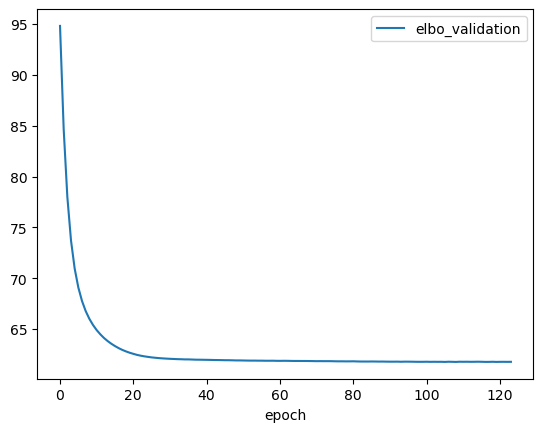

In [13]:
%%time
torch.cuda.empty_cache() 
torch.cuda.ipc_collect() 

scvi.external.CellAssign.setup_anndata(
    merge, 
    size_factor_key="size_factor",
)

model = CellAssign(merge, marker_mat)
model.train(
    max_epochs=200,
    lr=0.001,
    accelerator='gpu',
    shuffle_set_split=False,
)

model.history["elbo_validation"].plot()

In [14]:
preds = model.predict()
print(f"{preds.shape=}")
print(preds.head().to_string())

preds.shape=(119958, 3)
category  endothelial    fibroblast  hematopoietic
0            1.000000  0.000000e+00   0.000000e+00
1            0.961117  3.784776e-02   1.036013e-03
2            0.995847  1.122528e-19   4.152554e-03
3            1.000000  8.519895e-35   1.933167e-10
4            0.000017  9.999580e-01   2.532493e-05


In [15]:
# break

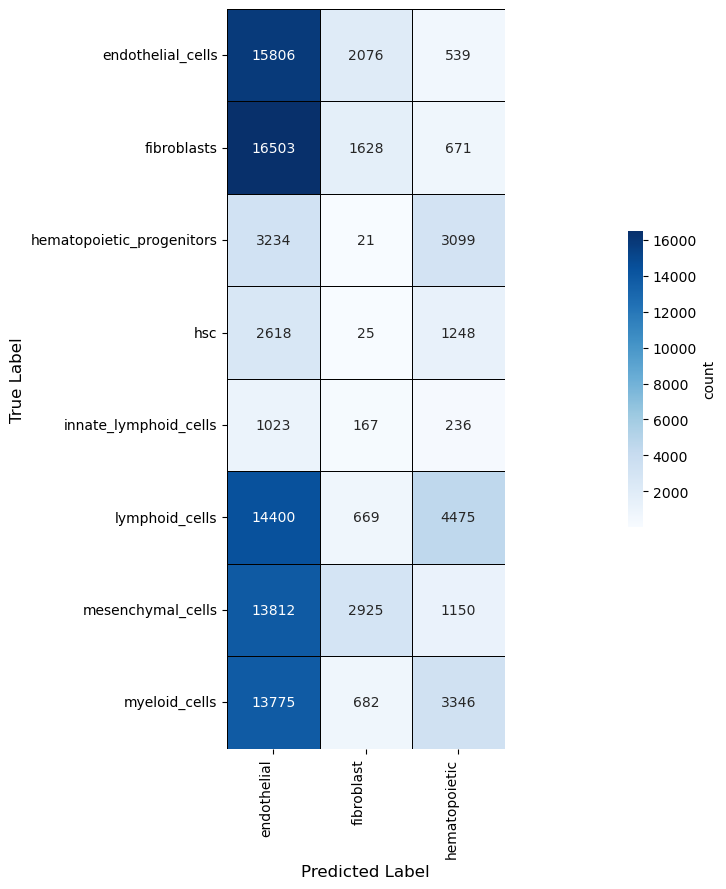

In [16]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix.drop(columns=['bj_fibroblast_control', 'reprogram'], inplace=True)
# confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(25, 9))  # Square aspect
plt.rcParams['figure.dpi'] = 200
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "count", "shrink": 0.4},
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

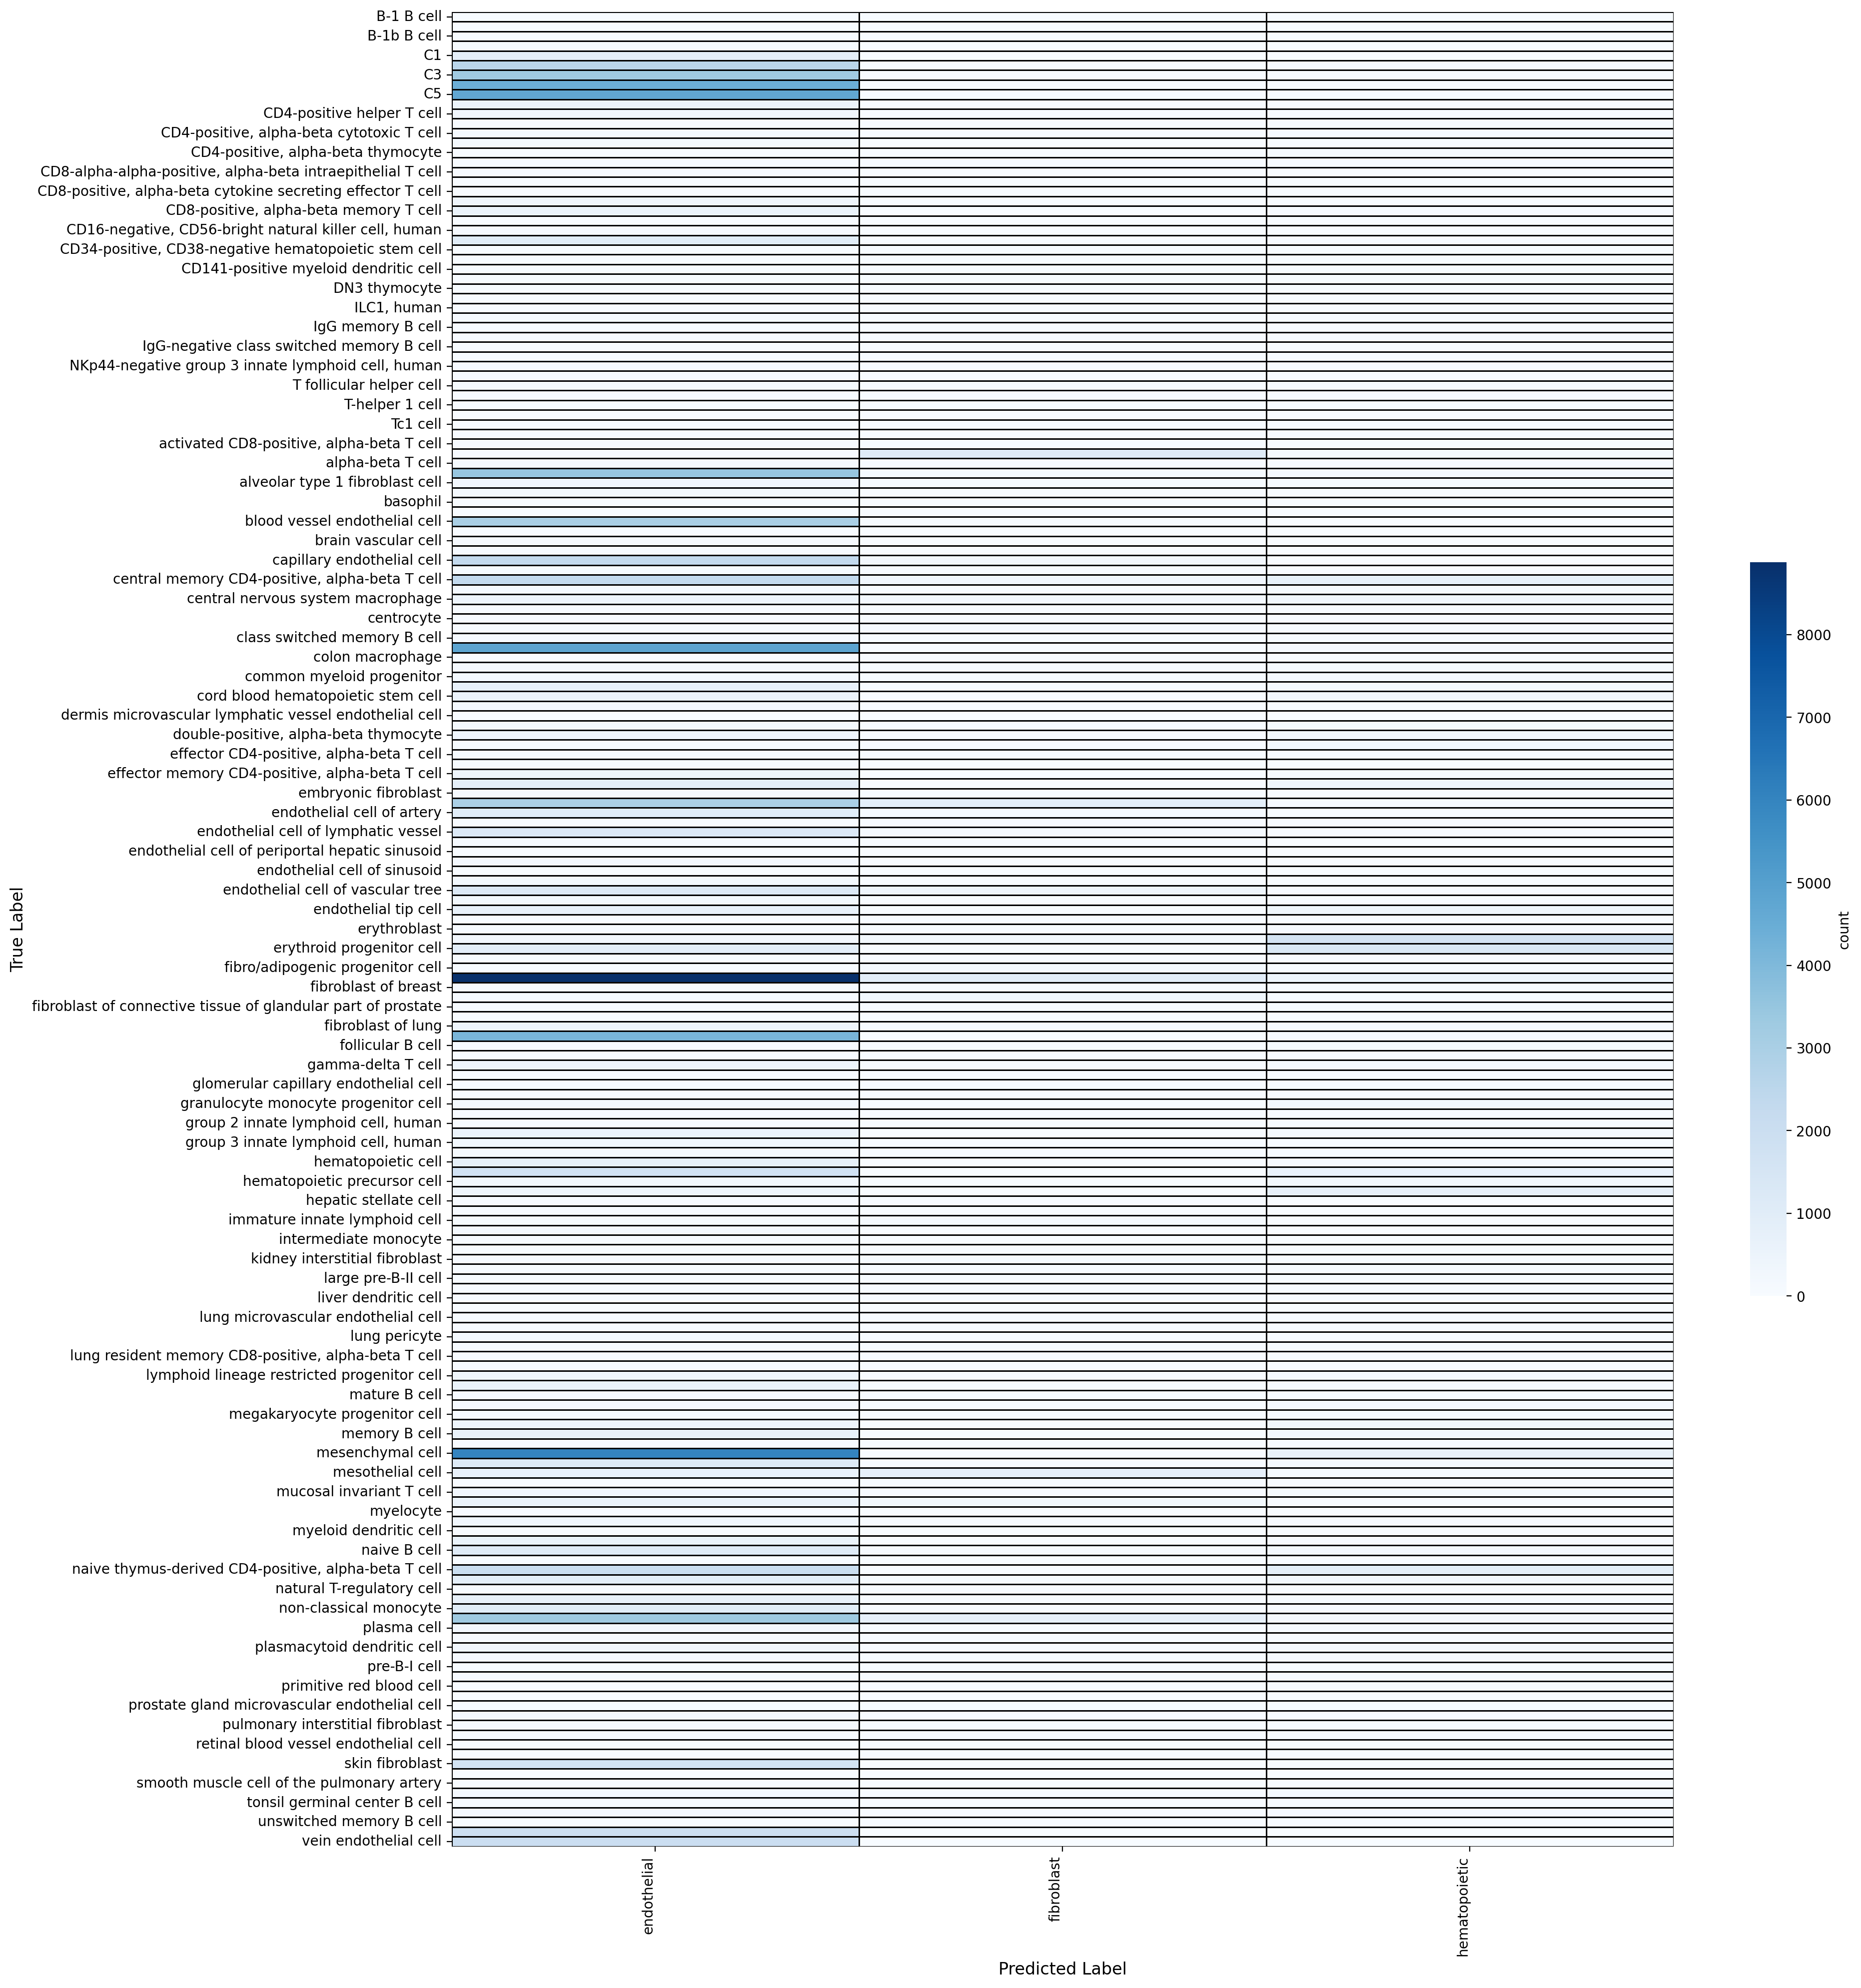

In [17]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['cell_type'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

# confusion_matrix /= confusion_matrix.sum(1).ravel().reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(20, 20))  # Square aspect
plt.rcParams['figure.dpi'] = 200
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    # square=True,
    cmap="Blues",  # Use "viridis" or "mako" for alternatives
    cbar_kws={"label": "count", "shrink": 0.4},
    # annot=True,
    # fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

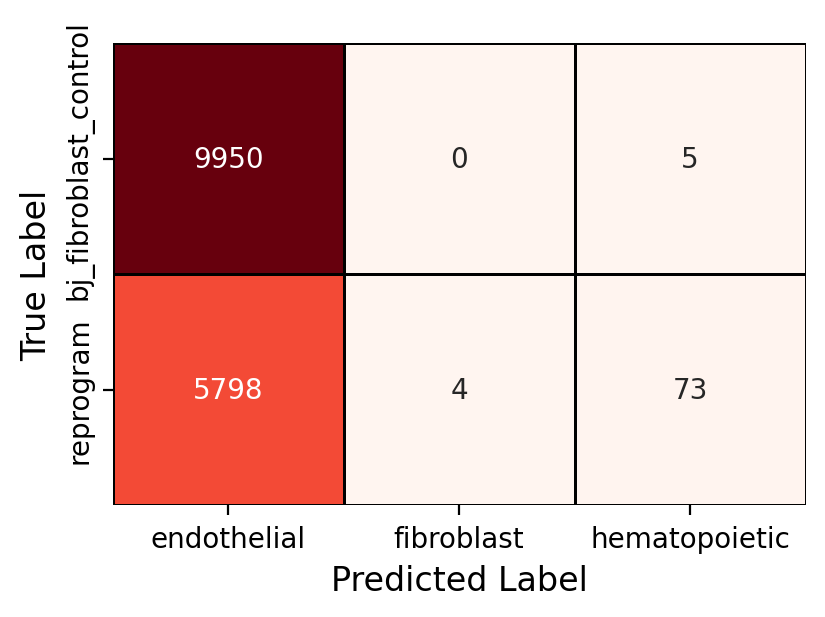

In [18]:
confusion_matrix = pd.crosstab(
    preds.idxmax(axis=1),
    merge.obs['basename'].values,
    rownames=["y Pred"],
    colnames=["y True"],
)

confusion_matrix = confusion_matrix[['bj_fibroblast_control', 'reprogram']]
confusion_matrix

# Plot
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(25, 3))  # Square aspect
sns.heatmap(
    confusion_matrix.T,
    ax=ax,
    square=True,
    cmap="Reds",  # Use "viridis" or "mako" for alternatives
    cbar=False,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='k'
)

# # Aesthetics
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
plt.show()

In [19]:
# break

# Differences in p(X)?

In [20]:
for col in preds.columns:
    merge.obs[col] = preds[col].values

merge

AnnData object with n_obs × n_vars = 119958 × 35
    obs: 'cell_type', 'nnz', 'basename', 'n_counts', 'n_genes', 'size_factor', 'cluster', 'pseudotime', 'phase', 'batch', '_scvi_batch', 'endothelial', 'fibroblast', 'hematopoietic'
    var: 'n_counts'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap'

In [21]:
merge.obs['basename'].value_counts()

basename
lymphoid_cells               19544
fibroblasts                  18802
endothelial_cells            18421
mesenchymal_cells            17887
myeloid_cells                17803
bj_fibroblast_control         9955
hematopoietic_progenitors     6354
reprogram                     5875
hsc                           3891
innate_lymphoid_cells         1426
Name: count, dtype: int64

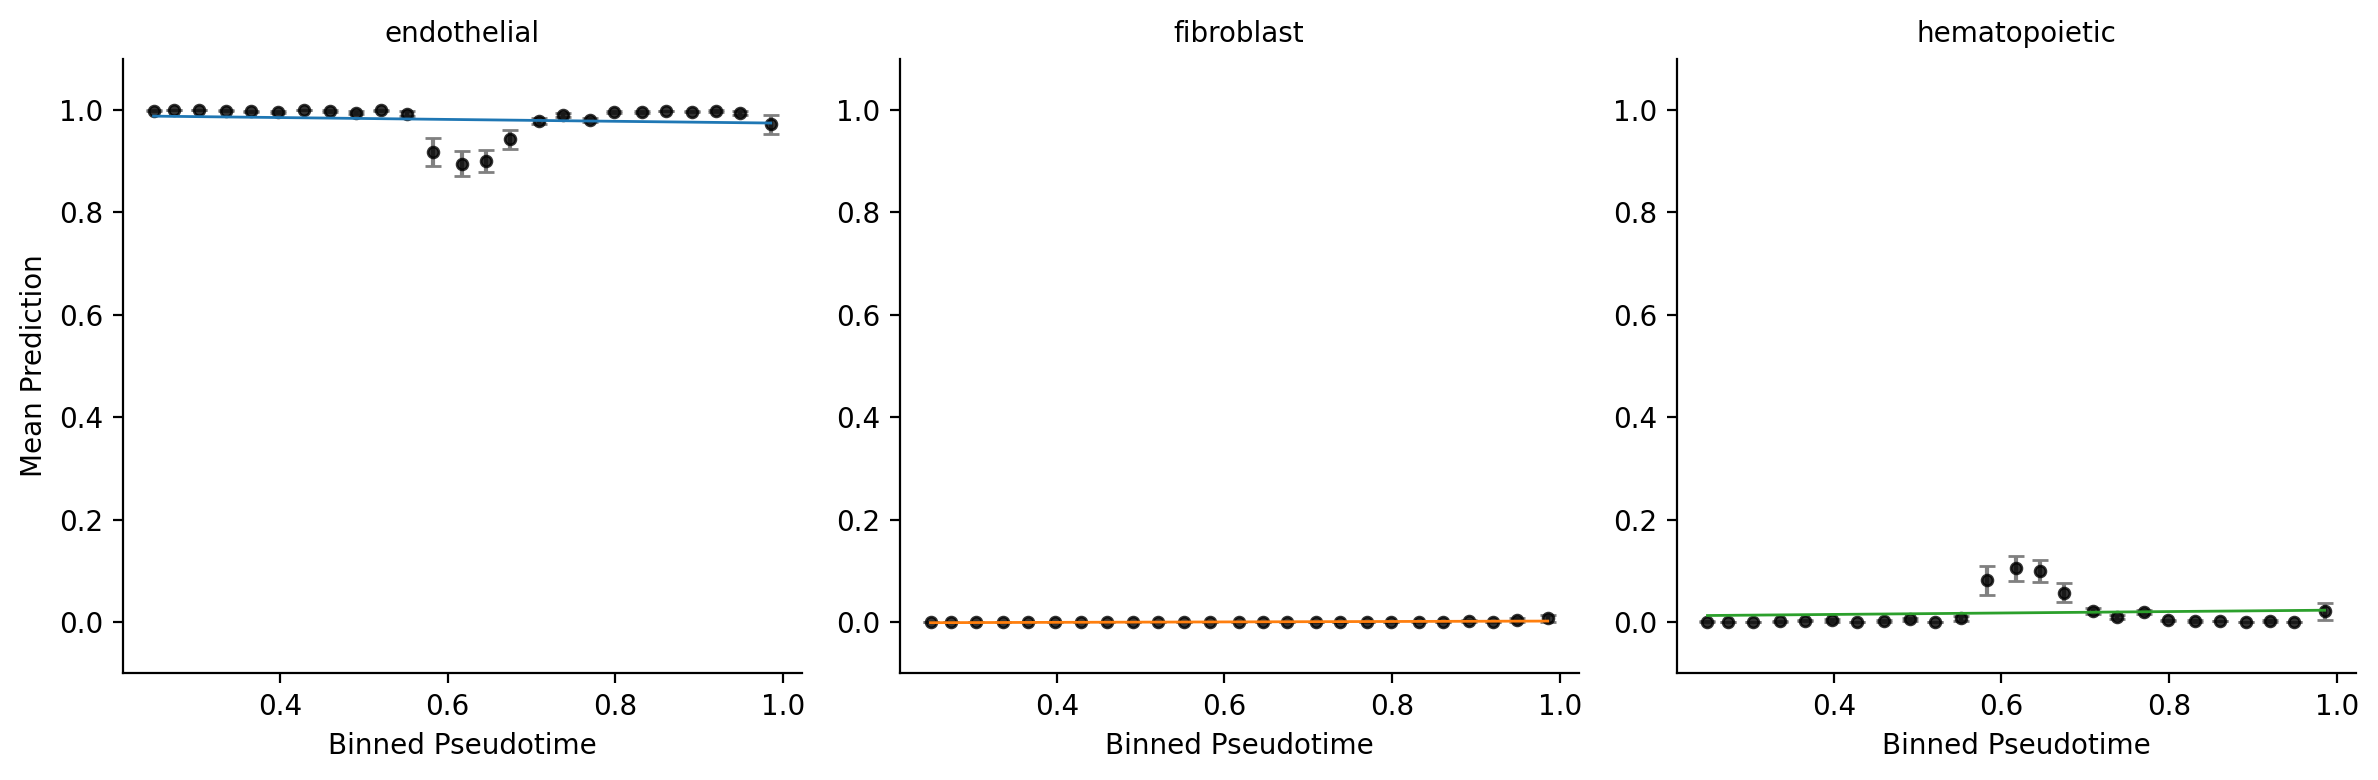

In [22]:
pdf = merge.obs[merge.obs['basename'].isin(['reprogram', 'bj_fibroblast_control'])].copy()
pdf = pdf.sort_values('cluster')

# Melt to long format
pdf = pd.melt(
    pdf,
    id_vars=['cluster', 'pseudotime'],
    value_vars=preds.columns,

)



pdf['value'] = pd.to_numeric(pdf['value'], errors='coerce')
pdf['pseudotime'] = pd.to_numeric(pdf['pseudotime'], errors='coerce')
pdf = pdf.dropna(subset=['pseudotime', 'value'])

# Bin pseudotime into 10 equal-width bins
pdf['pseudotime_bin'] = pd.cut(pdf['pseudotime'], bins=25, labels=False)

# Aggregate: mean, SEM × 1.96 for 95% CI
binned = pdf.groupby(['variable', 'pseudotime_bin'], observed=True).agg(
    pseudotime_mean=('pseudotime', 'mean'),
    value_mean=('value', 'mean'),
    value_sem=('value', lambda x: x.std(ddof=1) / np.sqrt(len(x)))  # SEM
).reset_index()
binned['value_ci95'] = binned['value_sem'] * 1.96  # 95% CI

# Faceted plot
g = sns.lmplot(
    data=binned,
    x='pseudotime_mean',
    y='value_mean',
    col='variable',
    col_wrap=3,
    hue='variable',
    sharey=False,
    height=4,
    scatter_kws={'s': 15, 'color': 'k'},
    line_kws={'linewidth': 1},
    ci=None
)


# Add 95% CI bars manually
for ax, (name, subdf) in zip(g.axes.flat, binned.groupby('variable', observed=True)):
    ax.errorbar(
        subdf['pseudotime_mean'],
        subdf['value_mean'],
        yerr=subdf['value_sem'],
        fmt='none',
        ecolor='gray',
        elinewidth=1.5,
        capsize=3,
        zorder=0,
    )

g.set_titles("{col_name}")
g.set_axis_labels("Binned Pseudotime", "Mean Prediction")
g.set(ylim=(-.1, 1.1))  # <-- set y-axis limits here
plt.tight_layout()
plt.show()


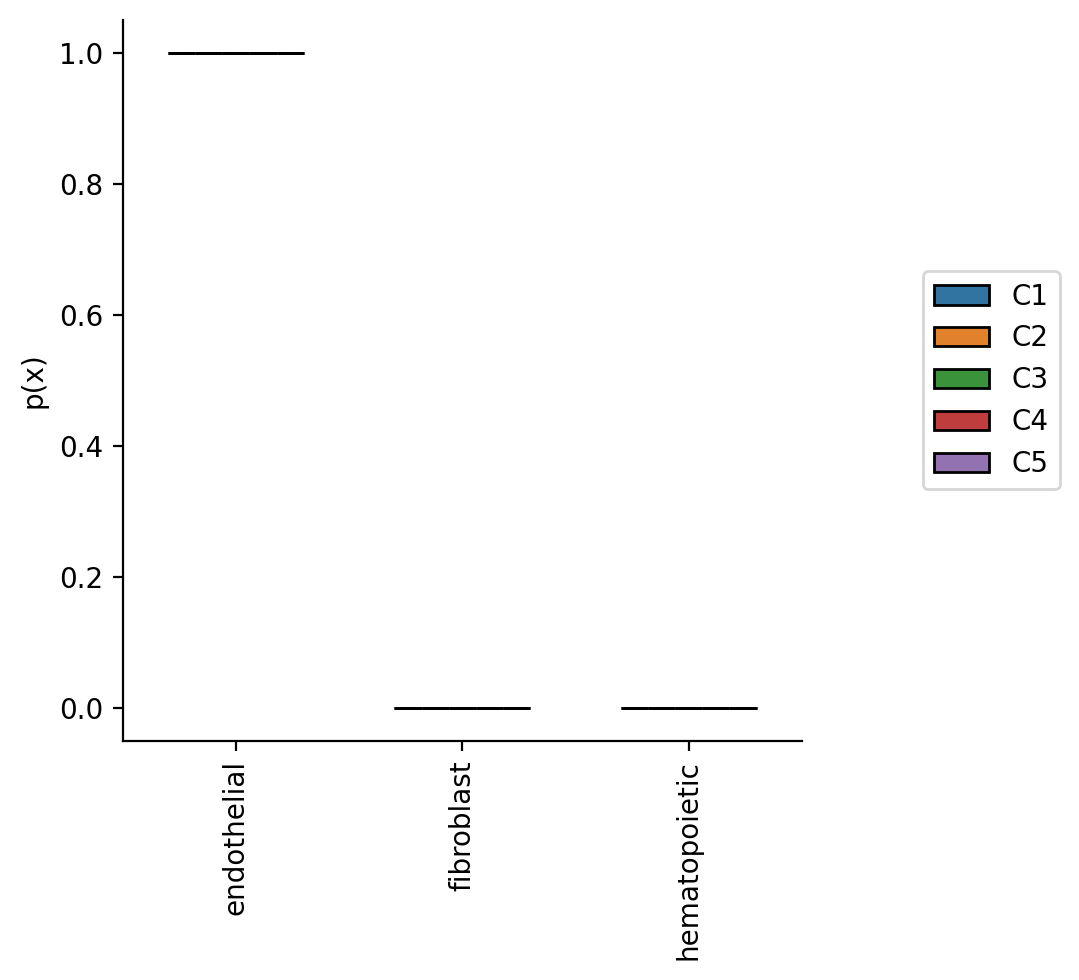

In [23]:
pdf = merge.obs[merge.obs['basename'].isin(['reprogram', 'bj_fibroblast_control'])].copy()
pdf = pdf.sort_values('cluster')

# Melt to long format
plot_df = pd.melt(
    pdf,
    id_vars=['cluster'],
    value_vars=preds.columns,
    var_name='cell_type',
    value_name='score'
)

# Boxplot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=plot_df,
    x='cell_type',
    y='score',
    hue='cluster',
    showfliers=False,
    width=0.6,
    linewidth=1,
    linecolor='k',
)

# Clean axis labels and ticks
ax.set_xlabel("")
ax.set_ylabel("p(x)")
ax.tick_params(axis='x', labelrotation=90)
ax.legend(title='', loc='center right', fontsize=10, title_fontsize=11, bbox_to_anchor=(1.4,0.5))
sns.despine()

plt.tight_layout()


In [24]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)